In [1]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import pandas as pd
import numpy as np
import pickle
import os
import corner
import matplotlib.pyplot as plt

# from fit_dynesty import cpu_dynesty_fit, gpu_dynesty_fit
# from prior import prior_transform
# from likelihoods import dynesty_logl, logl
from main import model_for_plotting


In [2]:
path = '/Users/hanyuan/Dropbox/python_script/SchwarMAX/'
df_ic = pd.read_csv(path + 'mock_initial_conditions_xyz.csv')
df_ic = df_ic[np.sqrt(df_ic['x']**2 + df_ic['y']**2) < 15.0]
df_ic = df_ic[np.fabs(df_ic['z']) < 4.0]

n_particles =  20_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(df_ic['x']), size=n_particles, replace=False)
df_ic = df_ic.iloc[index]
# w0 = jnp.array([df_ic['x'], df_ic['y'], df_ic['z'], df_ic['vx'], df_ic['vy'], df_ic['vz']]).T
w0 = jnp.array(df_ic[['x','y','z']].to_numpy())


with open(path + 'mock_axisymmetric_disc_XY_withRot.pkl', 'rb') as f:
    bin_dict = pickle.load(f)

# regular grid parameters
nX, nY = bin_dict['nX_nY']
X_min, X_max = bin_dict['X_minmax']
Y_min, Y_max = bin_dict['Y_minmax']
X_regular_grid = bin_dict['X_regular_grid']
Y_regular_grid = bin_dict['Y_regular_grid']

# voronoi binning mapping and data
xy_vbins = bin_dict['voronoi_bins_xy']
num_per_bin = jnp.array(bin_dict['num_per_bin'])
total_bins = jnp.array(bin_dict['total_bins'])
bin_mapping = jnp.array(bin_dict['bin_mapping'])
surface_density = jnp.array(bin_dict['surface_density'])
V_data = jnp.array(bin_dict['V_mean'])
sigma_data = jnp.array(bin_dict['V_sigma'])
h1_data = jnp.array(bin_dict['h1'])
h2_data = jnp.array(bin_dict['h2'])
h3_data = jnp.array(bin_dict['h3'])
h4_data = jnp.array(bin_dict['h4'])
v0 = jnp.array(bin_dict['v0'])
s = jnp.array(bin_dict['s'])
alpha, beta, gamma = bin_dict['orientation']
# alpha, beta, gamma = 0,0,0

V_data_err = jnp.where(0.1 * jnp.fabs(V_data) < 10, 10, 0.1 * V_data)
sigma_data_err = jnp.where(0.1 * jnp.fabs(sigma_data) < 5, 5, 0.1 * sigma_data)
h1_data_err = jnp.where(0.1 * jnp.fabs(h1_data) < 0.03, 0.03, 0.1 * jnp.fabs(h1_data))
h2_data_err = jnp.where(0.1 * jnp.fabs(h2_data) < 0.03, 0.03, 0.1 * jnp.fabs(h2_data))
h3_data_err = jnp.where(0.1 * jnp.fabs(h3_data) < 0.03, 0.03, 0.1 * jnp.fabs(h3_data))
h4_data_err = jnp.where(0.1 * jnp.fabs(h4_data) < 0.03, 0.03, 0.1 * jnp.fabs(h4_data))

df_Rzphi_data = pd.read_csv(path + 'mock_axisymmetric_disc_Rzphi.csv')
Rzphi_density_data = jnp.array(df_Rzphi_data['mass'].to_numpy()).astype(jnp.float32)
with open(path + 'mock_axisymmetric_disc_Rzphi.pkl', 'rb') as f:
    Rzphi_density_data_load = pickle.load(f)

R_grid, z_grid, phi_grid = Rzphi_density_data_load['R_grid'], Rzphi_density_data_load['z_grid'], Rzphi_density_data_load['phi_grid']
dR = np.unique(R_grid)[1] - np.unique(R_grid)[0]
dz = np.unique(z_grid)[1] - np.unique(z_grid)[0]
dphi = np.unique(phi_grid)[1] - np.unique(phi_grid)[0]
sample_for_integration = Rzphi_density_data_load['sample_for_integration']
# Rzphi_density_data = jnp.array([
#         get_mass(R_grid[i], z_grid[i], phi_grid[i], dR, dz, dphi,
#                 dict_data['sample_for_integration']) for i in range(len(R_grid))
#     ]).astype(jnp.float32)
dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': surface_density,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'num_per_bin': num_per_bin,
    'bin_mapping': bin_mapping,
    'total_bins': total_bins.item(),
    'R_grid': R_grid,
    'z_grid': z_grid,
    'phi_grid': phi_grid,
    'dR': dR,   
    'dz': dz,
    'dphi': dphi,
    'sample_for_integration': sample_for_integration
}


with open(path + '/mock_axisymmetric_disc_potential_params.pkl', 'rb') as f:
    gt_params = pickle.load(f)

N = 20
i = 10
ground_truth = {
        'logM_halo': gt_params['halo_params']['logM'].item() + (i-N/2)/10,
        'logRs_halo': jnp.log10(gt_params['halo_params']['scaleRadius']).item(),
        'logM_disk': gt_params['disc_params']['logM'].item(),
        'logRs_disk': jnp.log10(gt_params['disc_params']['scaleRadius']).item(),
        'logHs_disk': jnp.log10(gt_params['disc_params']['scaleHeight']).item(),
        'alpha': alpha,
        'beta': beta,
        'gamma': gamma
}

print('Ground truth parameters:')
for key, value in ground_truth.items():
    print(f'{key}: {value}')

20000
Ground truth parameters:
logM_halo: 11.698970004336019
logRs_halo: 1.1760913133621216
logM_disk: 10.602059991327963
logRs_disk: 0.4771212637424469
logHs_disk: -0.3010300099849701
alpha: 30
beta: 20
gamma: 0


In [4]:
params_halo_pot = {
    'logM': ground_truth['logM_halo'],
    'Rs':10 ** ground_truth['logRs_halo'],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': ground_truth['logM_disk'],
    'Rs': 10 ** ground_truth['logRs_disk'],
    'Hs': 10 ** ground_truth['logHs_disk'],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0,
    'alpha': ground_truth['alpha'],
    'beta': ground_truth['beta'],
    'gamma': ground_truth['gamma']
}
density_set, V_model, sigma_model, h1_set, h2_set, h3_set, h4_set,\
density_unity_set, V_model_unity, sigma_model_unity, h1_unity_set, h2_unity_set, h3_unity_set, h4_unity_set,\
        weights = model_for_plotting(params_halo_pot, params_disk_rho, dict_data, dict_data['total_bins'])

density_2DXY, y_xy, sig_xy = density_set
h1_model, y_h1, sig_A1 = h1_set
h2_model, y_h2, sig_A2 = h2_set
h3_model, y_h3, sig_A3 = h3_set
h4_model, y_h4, sig_A4 = h4_set

density_2DXY_unity, y_xy, sig_xy = density_unity_set
h1_unity_model, y_h1, sig_A1 = h1_unity_set
h2_unity_model, y_h2, sig_A2 = h2_unity_set
h3_unity_model, y_h3, sig_A3 = h3_unity_set
h4_unity_model, y_h4, sig_A4 = h4_unity_set

weights.block_until_ready()
print('Done')

Done


In [5]:
EPSILON = 1e-12
res_density = ((density_2DXY - y_xy) / (sig_xy + EPSILON))**2
res_h1 = ((h1_model - h1_data) / (h1_data_err + 1e-3))**2
res_h2 = ((h2_model - h2_data) / (h2_data_err + 1e-3))**2
res_h3 = ((h3_model - h3_data) / (h3_data_err + 1e-3))**2
res_h4 = ((h4_model - h4_data) / (h4_data_err + 1e-3))**2    

res_density = jnp.where(res_density<jnp.percentile(res_density, 98.0), res_density, 0)
res_h1 = jnp.where(res_h1<jnp.percentile(res_h1, 98.0), res_h1, 0)
res_h2 = jnp.where(res_h2<jnp.percentile(res_h2, 98.0), res_h2, 0)
res_h3 = jnp.where(res_h3<jnp.percentile(res_h3, 98.0), res_h3, 0)
res_h4 = jnp.where(res_h4<jnp.percentile(res_h4, 98.0), res_h4, 0)

val1 = jnp.nansum( -0.5 * res_density ) / len(density_2DXY)
val4 = jnp.nansum( -0.5 * res_h1 ) / len(h1_model)
val5 = jnp.nansum( -0.5 * res_h2 ) / len(h2_model)
val6 = jnp.nansum( -0.5 * res_h3 ) / len(h3_model)
val7 = jnp.nansum( -0.5 * res_h4 ) / len(h4_model)

log_likelihood = 0
log_likelihood += val1 + val4 + val5 + val6 + val7
print('Log-likelihood:', log_likelihood)

Log-likelihood: -7.9871798


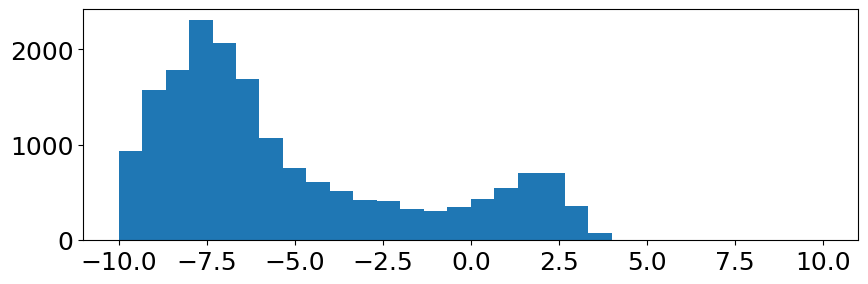

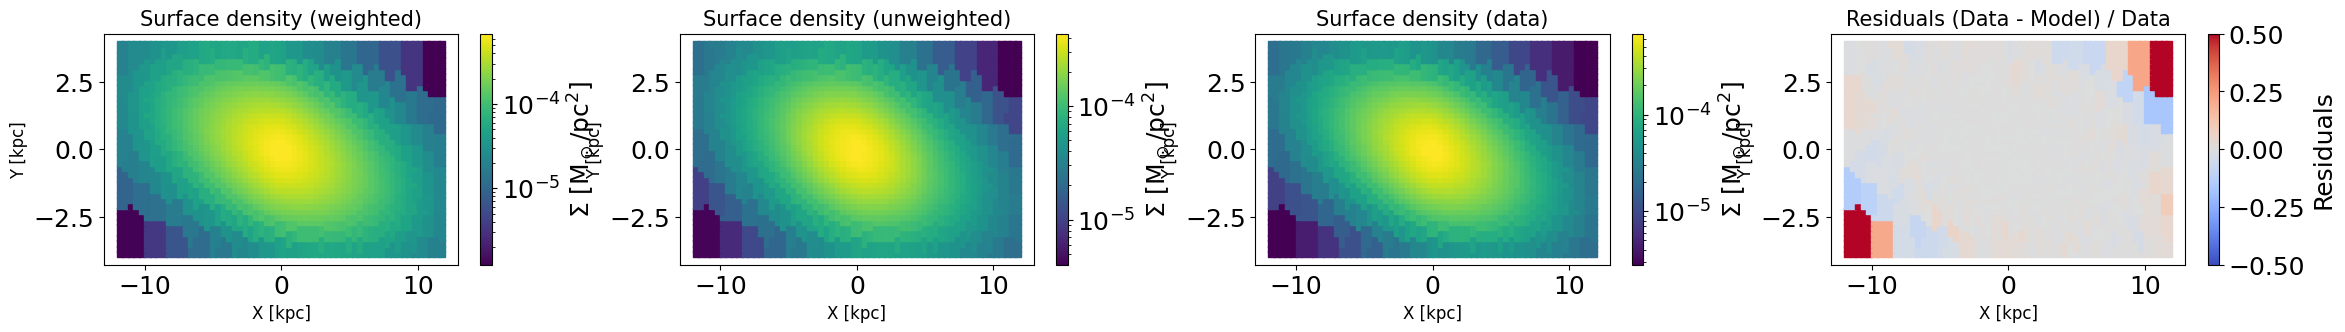

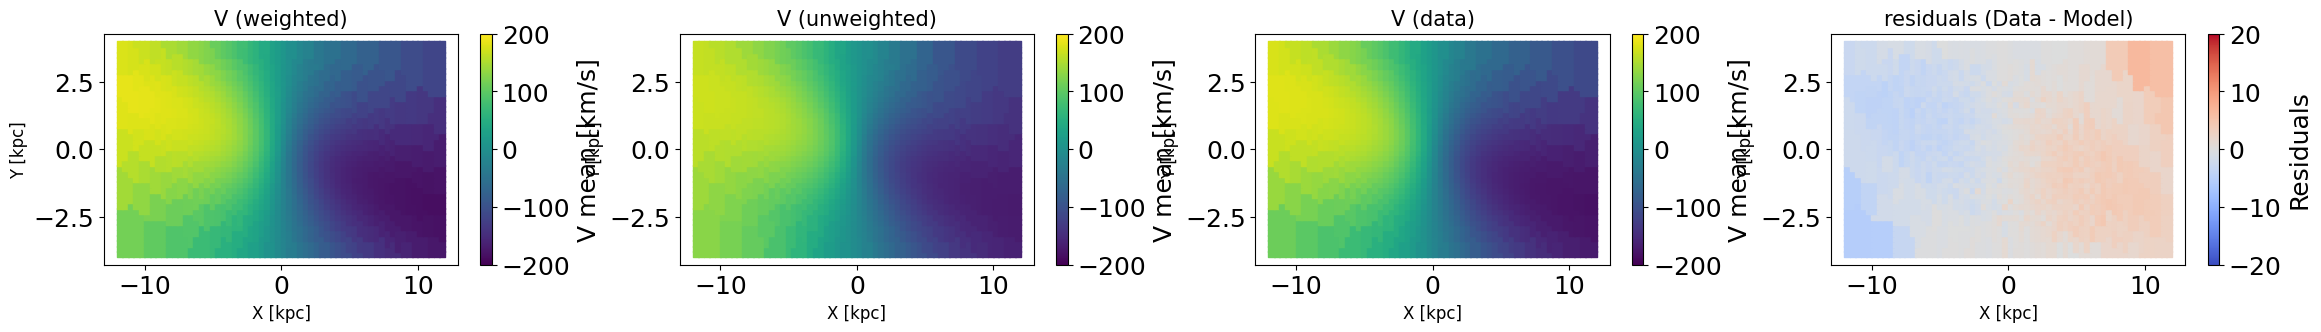

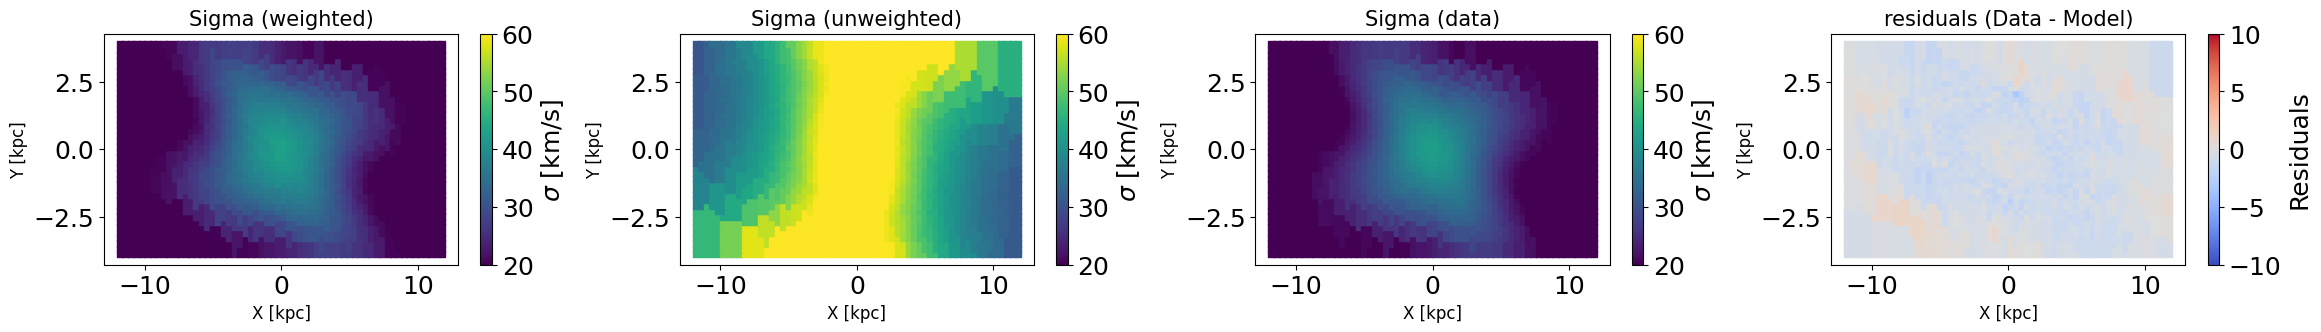

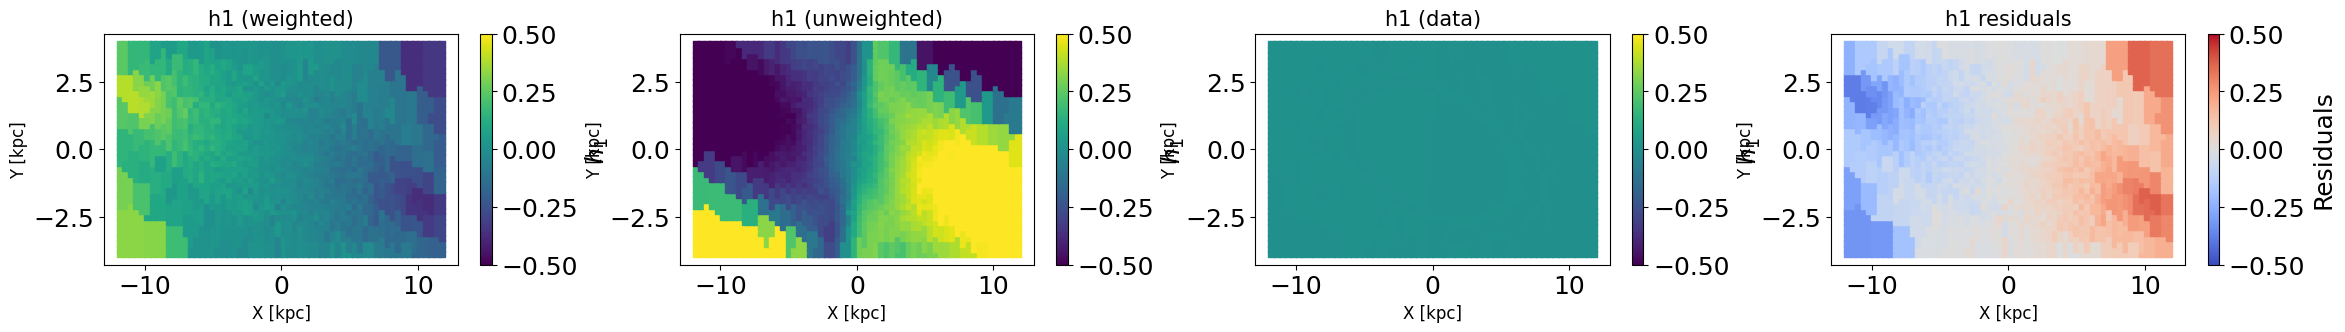

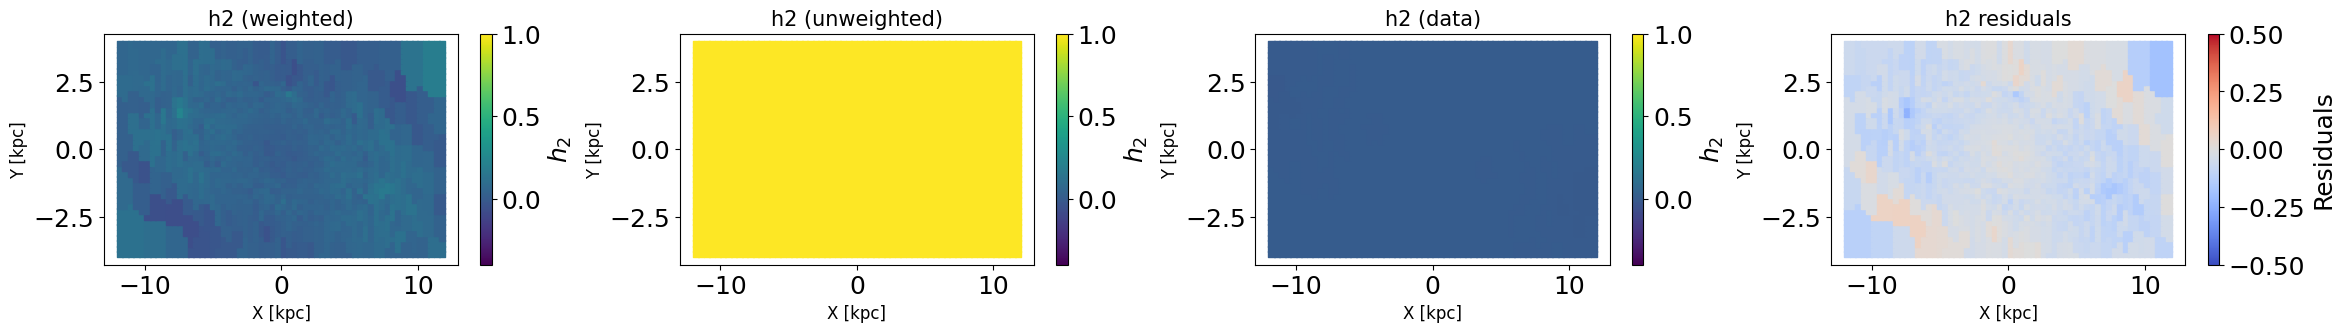

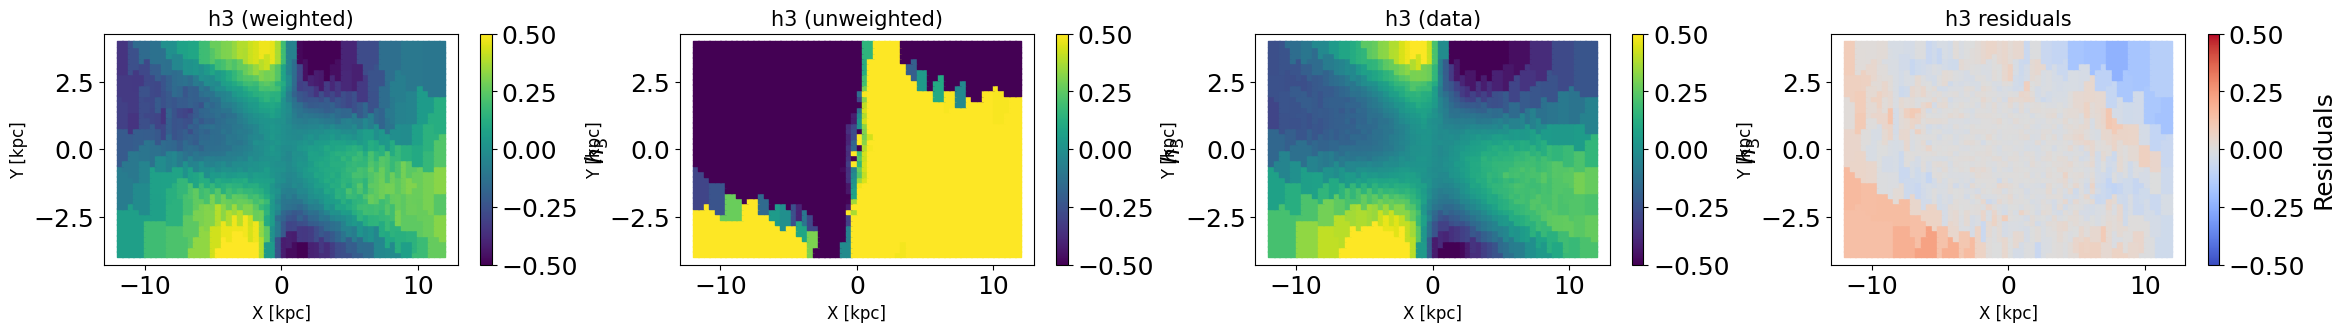

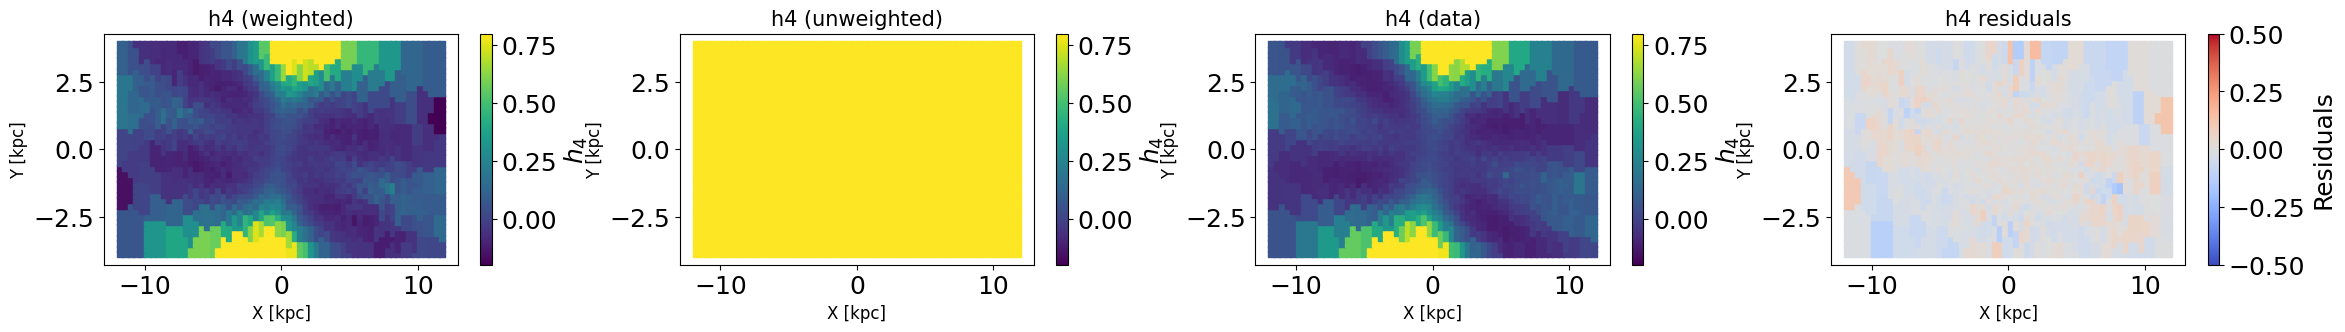

In [6]:
fig, ax = plt.subplots(1,1,figsize = (10,3))
ax.hist(jnp.log(weights), range=(-10,10), bins=30)

mean_mass_per_orb = jnp.sum(Rzphi_density_data) / len(weights)
index_remap = bin_mapping[:-1]

density_2DXY_weighted = density_2DXY[index_remap]
V_model_weighted = V_model[index_remap]
sigma_model_weighted = sigma_model[index_remap]
h1_model_weighted = h1_model[index_remap]
h2_model_weighted = h2_model[index_remap]
h3_model_weighted = h3_model[index_remap]
h4_model_weighted = h4_model[index_remap]

_density_2DXY_unity = density_2DXY_unity[index_remap]
_V_model_unity = V_model_unity[index_remap]
_sigma_model_unity = sigma_model_unity[index_remap]
_h1_model_unity = h1_unity_model[index_remap]
_h2_model_unity = h2_unity_model[index_remap]
_h3_model_unity = h3_unity_model[index_remap]
_h4_model_unity = h4_unity_model[index_remap]

density_2DXY_data = surface_density[index_remap]
V_model_data = V_data[index_remap]
sigma_model_data = sigma_data[index_remap]
h1_model_data = h1_data[index_remap]
h2_model_data = h2_data[index_remap]
h3_model_data = h3_data[index_remap]
h4_model_data = h4_data[index_remap]

# fig1,ax1 = plt.subplots(2,4,figsize=(30,7), gridspec_kw={'hspace':0.5, 'wspace':0.3})
# fig1.suptitle('2D spatial and kinematic maps in Voronoi bins', fontsize=20, y = 1.03)
# cb1 = ax1[0,0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted, 
#                 s = 20, cmap='viridis', marker = 's', norm = 'log')
# fig1.colorbar(cb1, ax=ax1[0,0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')
# ax1[0,0].set_title('Surface density')
# ax1[0,0].set_xlabel('X [kpc]')
# ax1[0,0].set_ylabel('Y [kpc]')

fig0, ax0 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax0[0].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_weighted,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[0].set_title('Surface density (weighted)', fontsize=15)
ax0[0].set_xlabel('X [kpc]', fontsize=12)
ax0[0].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[0], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

cb = ax0[1].scatter(X_regular_grid, Y_regular_grid, c=_density_2DXY_unity,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[1].set_title('Surface density (unweighted)', fontsize=15)
ax0[1].set_xlabel('X [kpc]', fontsize=12)
ax0[1].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[1], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

cb = ax0[2].scatter(X_regular_grid, Y_regular_grid, c=density_2DXY_data / mean_mass_per_orb,
                s = 20, cmap='viridis', marker = 's', norm = 'log')
ax0[2].set_title('Surface density (data)', fontsize=15)
ax0[2].set_xlabel('X [kpc]', fontsize=12)
ax0[2].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[2], label=r'$\Sigma$ [M$_\odot$/pc$^2$]')

res = (density_2DXY_data / mean_mass_per_orb - density_2DXY_weighted) / (density_2DXY_data / mean_mass_per_orb)
cb = ax0[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax0[3].set_title('Residuals (Data - Model) / Data', fontsize=15)
ax0[3].set_xlabel('X [kpc]', fontsize=12)
ax0[3].set_ylabel('Y [kpc]', fontsize=12)
fig0.colorbar(cb, ax=ax0[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=V_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[0].set_title('V (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'V mean [km/s]')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_V_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[1].set_title('V (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'V mean [km/s]')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=V_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -200, vmax = 200)
ax1[2].set_title('V (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12) 
fig1.colorbar(cb, ax=ax1[2], label=r'V mean [km/s]')

res = (V_model_data - V_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -20, vmax = 20)
ax1[3].set_title('residuals (Data - Model)', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[0].set_title('Sigma (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$\sigma$ [km/s]')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_sigma_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[1].set_title('Sigma (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$\sigma$ [km/s]')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=sigma_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = 20, vmax = 60)
ax1[2].set_title('Sigma (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$\sigma$ [km/s]')

res = (sigma_model_data - sigma_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -10, vmax = 10)
ax1[3].set_title('residuals (Data - Model)', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h1_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[0].set_title('h1 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_1$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h1_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[1].set_title('h1 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_1$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h1_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[2].set_title('h1 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_1$')

res = (h1_model_data - h1_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h1 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h2_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[0].set_title('h2 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_2$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h2_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[1].set_title('h2 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_2$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h2_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.4, vmax = 1)
ax1[2].set_title('h2 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_2$')

res = (h2_model_data - h2_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h2 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h3_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[0].set_title('h3 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_3$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h3_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[1].set_title('h3 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_3$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h3_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[2].set_title('h3 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_3$')

res = (h3_model_data - h3_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h3 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')

# =============================================================================================

fig1, ax1 = plt.subplots(1,4, figsize = (28,3), gridspec_kw={'hspace':0.5, 'wspace':0.3})

cb = ax1[0].scatter(X_regular_grid, Y_regular_grid, c=h4_model_weighted,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[0].set_title('h4 (weighted)', fontsize=15)
ax1[0].set_xlabel('X [kpc]', fontsize=12)
ax1[0].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[0], label=r'$h_4$')

cb = ax1[1].scatter(X_regular_grid, Y_regular_grid, c=_h4_model_unity,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[1].set_title('h4 (unweighted)', fontsize=15)
ax1[1].set_xlabel('X [kpc]', fontsize=12)
ax1[1].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[1], label=r'$h_4$')

cb = ax1[2].scatter(X_regular_grid, Y_regular_grid, c=h4_model_data,
                s = 20, cmap='viridis', marker = 's', vmin = -0.2, vmax = 0.8)
ax1[2].set_title('h4 (data)', fontsize=15)
ax1[2].set_xlabel('X [kpc]', fontsize=12)
ax1[2].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[2], label=r'$h_4$')

res = (h4_model_data - h4_model_weighted)
cb = ax1[3].scatter(X_regular_grid, Y_regular_grid, c=res,
                s = 20, cmap='coolwarm', marker = 's', vmin = -0.5, vmax = 0.5)
ax1[3].set_title('h4 residuals', fontsize=15)
ax1[3].set_xlabel('X [kpc]', fontsize=12)
ax1[3].set_ylabel('Y [kpc]', fontsize=12)
fig1.colorbar(cb, ax=ax1[3], label='Residuals')